# Лабораторна 3 — Дворівнева нейронна мережа з нуля

**Курс:** Машинне навчання. Частина 2  
**Тиждень:** 3  
**Тема:** Дворівнева нейронна мережа з нуля

## Цілі лабораторної

- Реалізувати прямий та зворотній хід двошарової нейронної мережі за допомогою NumPy
- Перевірити градієнти методом чисельної апроксимації
- Дослідити вплив прихованого шару на форму межі рішення
- Порівняти різні функції активації

## Налаштування середовища

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Jupyter display
%matplotlib inline

# Reproducibility
np.random.seed(42)

# Add course modules to path
import sys
from pathlib import Path

course_root = Path.cwd()
if 'course' in course_root.parts:
    while course_root.name != 'course' and course_root.parent != course_root:
        course_root = course_root.parent
else:
    course_root = course_root / 'course'

modules_path = course_root / 'modules'
if str(modules_path) not in sys.path:
    sys.path.insert(0, str(modules_path))

# Apply shared colorblind-safe plot style
from plot_style import setup_plot_style, COLORBLIND_PALETTE
setup_plot_style()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import importlib
import nn_solution as nn   
importlib.reload(nn)      

SEED = 42


In [4]:
# ── Datasets ────────────────────────────────────────────────────────────────
X_moons,   y_moons   = make_moons(n_samples=400, noise=0.2, random_state=SEED)
X_circles, y_circles = make_circles(n_samples=400, noise=0.1,
                                    factor=0.5, random_state=SEED)

scaler = StandardScaler()
X_moons   = scaler.fit_transform(X_moons)
X_circles = scaler.fit_transform(X_circles)

# Train / test split
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=SEED)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_circles, y_circles, test_size=0.25, random_state=SEED)

print(f'Moons   - train: {Xm_tr.shape}, test: {Xm_te.shape}')
print(f'Circles - train: {Xc_tr.shape}, test: {Xc_te.shape}')

Moons   - train: (300, 2), test: (100, 2)
Circles - train: (300, 2), test: (100, 2)


In [5]:
# ── Shared helper ────────────────────────────────────────────────────────────
def plot_decision_boundary(predict_fn, X, y, title='', ax=None):
    ax = ax or plt.gca()
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
    x1 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    xx, yy = np.meshgrid(x0, x1)
    Z = predict_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolors='k', s=25, linewidths=0.4)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

---
## 1. Реалізація мережі

Виконуйте наступні клітинки **по черзі**. Кожна клітинка тестує одну функцію з n_student.py\.

### 1.1 Функції активації


In [6]:
# ── Test: sigmoid ──────────────────────────────────────────────────────────
z_test = np.array([-100.0, -2.0, 0.0, 2.0, 100.0])
s = nn.sigmoid(z_test)

# Use a moderate value to check (0,1) range - sigmoid(±100) saturates to
# exactly 0.0 / 1.0 in float64, which is expected and fine.
s_moderate = nn.sigmoid(np.array([-10.0, 10.0]))

print('sigmoid(z_test):', np.round(s, 5))
assert s.shape == z_test.shape,               'Shape mismatch'
assert abs(s[2] - 0.5) < 1e-9,               'sigmoid(0) should be 0.5'
assert abs(s[0] - 0.0) < 1e-5,               'sigmoid(-100) should be ~0'
assert abs(s[4] - 1.0) < 1e-5,               'sigmoid(100) should be ~1'
assert s_moderate[0] > 0 and s_moderate[1] < 1, 'Output must be in (0, 1) for moderate inputs'
print('✓ sigmoid OK')

sigmoid(z_test): [0.     0.1192 0.5    0.8808 1.    ]
✓ sigmoid OK


In [7]:
# ── Test: sigmoid_derivative ───────────────────────────────────────────────
ds = nn.sigmoid_derivative(z_test)
print('sigmoid_derivative(z_test):', np.round(ds, 5))
assert ds.shape == z_test.shape,              'Shape mismatch'
assert abs(ds[2] - 0.25) < 1e-9,             'σ\'(0) = 0.25'
assert ds.min() >= 0,                         'Derivative must be non-negative'
assert ds[0] < 1e-4 and ds[4] < 1e-4,        'Saturates at extremes'
print('✓ sigmoid_derivative OK')

sigmoid_derivative(z_test): [0.      0.10499 0.25    0.10499 0.     ]
✓ sigmoid_derivative OK


In [8]:
# ── Test: tanh_derivative ──────────────────────────────────────────────────
dt = nn.tanh_derivative(z_test)
print('tanh_derivative(z_test):', np.round(dt, 5))
assert dt.shape == z_test.shape,              'Shape mismatch'
assert abs(dt[2] - 1.0) < 1e-9,              'tanh\'(0) = 1.0'
assert dt.min() >= 0,                         'Derivative must be non-negative'
assert dt[0] < 1e-4 and dt[4] < 1e-4,        'Saturates at extremes'
print('✓ tanh_derivative OK')

tanh_derivative(z_test): [0.      0.07065 1.      0.07065 0.     ]
✓ tanh_derivative OK


### 1.2 Weight Initialisation

In [9]:
# ── Test: initialise_weights ───────────────────────────────────────────────
params = nn.initialise_weights(n_input=2, n_hidden=4, n_output=1, seed=SEED)

assert set(params.keys()) == {'W1', 'b1', 'W2', 'b2'}, 'Wrong keys'
assert params['W1'].shape == (4, 2),   f"W1 shape: {params['W1'].shape}"
assert params['b1'].shape == (4,),     f"b1 shape: {params['b1'].shape}"
assert params['W2'].shape == (1, 4),   f"W2 shape: {params['W2'].shape}"
assert params['b2'].shape == (1,),     f"b2 shape: {params['b2'].shape}"
assert np.allclose(params['b1'], 0),   'b1 should be zeros'
assert np.allclose(params['b2'], 0),   'b2 should be zeros'
assert abs(params['W1'].std() - np.sqrt(1/2)) < 0.3, \
    'W1 std should be ~sqrt(1/n_input)'

print('W1 std (expect ~0.71):', round(params['W1'].std(), 3))
print('W2 std (expect ~0.50):', round(params['W2'].std(), 3))
print('✓ initialise_weights OK')

W1 std (expect ~0.71): 0.683
W2 std (expect ~0.50): 0.349
✓ initialise_weights OK


### 1.3 Forward Pass

In [10]:
# ── Test: forward_pass ─────────────────────────────────────────────────────
X_small = Xm_tr[:5]
params  = nn.initialise_weights(2, 4, 1, seed=SEED)

A2, cache = nn.forward_pass(X_small, params)

assert A2.shape == (5, 1),          f'A2 shape: {A2.shape}'
assert A2.min() > 0 and A2.max() < 1, 'A2 must be in (0,1) - check sigmoid'
assert set(cache.keys()) == {'X', 'Z1', 'A1', 'Z2', 'A2'}, 'Missing cache keys'
assert cache['Z1'].shape == (5, 4), f"Z1 shape: {cache['Z1'].shape}"
assert cache['A1'].shape == (5, 4), f"A1 shape: {cache['A1'].shape}"
assert cache['A1'].min() > -1 and cache['A1'].max() < 1, \
    'A1 must be in (-1,1) - check tanh'

print(f'A2 (first 5 predictions): {A2.ravel().round(4)}')
print('✓ forward_pass OK')

A2 (first 5 predictions): [0.442  0.4124 0.7222 0.5127 0.5673]
✓ forward_pass OK


### 1.4 Loss

In [11]:
# ── Test: binary_cross_entropy ─────────────────────────────────────────────
# Perfect predictions → loss ≈ 0
y_true = np.array([1, 0, 1, 0])
A2_perfect = np.array([[0.9999], [0.0001], [0.9999], [0.0001]])
A2_bad     = np.array([[0.0001], [0.9999], [0.0001], [0.9999]])
A2_random  = np.array([[0.5], [0.5], [0.5], [0.5]])

loss_perfect = nn.binary_cross_entropy(A2_perfect, y_true)
loss_bad     = nn.binary_cross_entropy(A2_bad,     y_true)
loss_random  = nn.binary_cross_entropy(A2_random,  y_true)

print(f'Loss (perfect predictions):  {loss_perfect:.5f}  (expect ≈ 0)')
print(f'Loss (random 0.5):           {loss_random:.5f}  (expect ≈ 0.693)')
print(f'Loss (all wrong):            {loss_bad:.5f}  (expect >> 0.693)')

assert loss_perfect < 0.01,         'Perfect predictions should have near-zero loss'
assert loss_bad > loss_random,      'Wrong predictions should have higher loss'
assert abs(loss_random - np.log(2)) < 0.01, 'Random loss should be ≈ ln(2) = 0.693'
print('✓ binary_cross_entropy OK')

Loss (perfect predictions):  0.00010  (expect ≈ 0)
Loss (random 0.5):           0.69315  (expect ≈ 0.693)
Loss (all wrong):            9.21034  (expect >> 0.693)
✓ binary_cross_entropy OK


### 1.5 Backward Pass

In [12]:
# ── Test: backward_pass (shape check) ─────────────────────────────────────
params = nn.initialise_weights(2, 4, 1, seed=SEED)
A2, cache = nn.forward_pass(Xm_tr, params)
grads = nn.backward_pass(params, cache, ym_tr)

assert set(grads.keys()) == {'dW1', 'db1', 'dW2', 'db2'}, 'Wrong gradient keys'
assert grads['dW1'].shape == params['W1'].shape, \
    f"dW1 shape mismatch: {grads['dW1'].shape} vs {params['W1'].shape}"
assert grads['db1'].shape == params['b1'].shape, \
    f"db1 shape mismatch"
assert grads['dW2'].shape == params['W2'].shape, \
    f"dW2 shape mismatch: {grads['dW2'].shape} vs {params['W2'].shape}"
assert grads['db2'].shape == params['b2'].shape, \
    f"db2 shape mismatch"

print('dW1:', grads['dW1'].shape, '  db1:', grads['db1'].shape)
print('dW2:', grads['dW2'].shape, '  db2:', grads['db2'].shape)
print('✓ backward_pass shapes OK - run gradient check next!')

dW1: (4, 2)   db1: (4,)
dW2: (1, 4)   db2: (1,)
✓ backward_pass shapes OK - run gradient check next!


---
## 2. Перевірка градієнтів

Перевірка градієнтів — потужний інструмент налагодження: вона порівнює аналітичні градієнти з **чисельними**, обчисленими методом скінченних різниць:

\$\$\frac{\partial \mathcal{L}}{\partial \theta_i} \approx
  \frac{\mathcal{L}(\theta_i + \varepsilon) - \mathcal{L}(\theta_i - \varepsilon)}{2\varepsilon}\$\$

Ми використовуємо мале \$\varepsilon = 10^{-5}\$ і вважаємо, що градієнт правильний, якщо відносна похибка менше \^{-5}\$.

In [13]:
def gradient_check(X, y, n_hidden=3, eps=1e-5, seed=0):
    """Compare analytical gradients to numerical gradients."""
    importlib.reload(nn)
    params = nn.initialise_weights(X.shape[1], n_hidden, 1, seed=seed)
    A2, cache = nn.forward_pass(X, params)
    grads = nn.backward_pass(params, cache, y)

    print(f'  {"Parameter":<6}  {"Analytical":>14}  {"Numerical":>14}  {"Rel. diff":>12}  Status')
    print('  ' + '─' * 65)

    all_ok = True
    for key in ('W1', 'b1', 'W2', 'b2'):
        param = params[key]
        grad_analytical = grads['d' + key].ravel()
        grad_numerical  = np.zeros_like(param)

        for idx in np.ndindex(param.shape):
            original = param[idx]

            param[idx] = original + eps
            A2p, _ = nn.forward_pass(X, params)
            loss_p = nn.binary_cross_entropy(A2p, y)

            param[idx] = original - eps
            A2m, _ = nn.forward_pass(X, params)
            loss_m = nn.binary_cross_entropy(A2m, y)

            param[idx] = original
            grad_numerical[idx] = (loss_p - loss_m) / (2 * eps)

        grad_numerical = grad_numerical.ravel()
        rel_diff = (np.linalg.norm(grad_analytical - grad_numerical) /
                    (np.linalg.norm(grad_analytical) +
                     np.linalg.norm(grad_numerical) + 1e-12))

        status = '✓' if rel_diff < 1e-5 else '✗ BUG'
        if rel_diff >= 1e-5:
            all_ok = False
        print(f'  {key:<6}  {grad_analytical.mean():>14.6f}  '
              f'{grad_numerical.mean():>14.6f}  {rel_diff:>12.2e}  {status}')

    print()
    if all_ok:
        print('✓ All gradients pass the check!')
    else:
        print('✗ Some gradients are wrong - check your backward_pass implementation.')


# Use a small subset for speed (numerical grad check is O(params) forward passes)
print('Gradient check on Moons (20 samples, 3 hidden neurons):')
gradient_check(Xm_tr[:20], ym_tr[:20], n_hidden=3)

Gradient check on Moons (20 samples, 3 hidden neurons):
  Parameter      Analytical       Numerical     Rel. diff  Status
  ─────────────────────────────────────────────────────────────────
  W1            0.023426        0.023426      2.97e-11  ✓
  b1            0.002776        0.002776      5.85e-10  ✓
  W2            0.012214        0.012214      1.92e-11  ✓
  b2            0.003104        0.003104      1.44e-10  ✓

✓ All gradients pass the check!


---
## 3. - Training, Evaluation & sklearn Comparison

### 3.1 Train Your Network

In [14]:
importlib.reload(nn)

print('=== Moons ===')
params_m, loss_m = nn.train(Xm_tr, ym_tr, n_hidden=8, lr=0.5,
                             n_epochs=1000, seed=SEED)

print('\n=== Circles ===')
params_c, loss_c = nn.train(Xc_tr, yc_tr, n_hidden=8, lr=0.5,
                             n_epochs=1000, seed=SEED)

=== Moons ===
  Epoch     0  loss=0.7593
  Epoch   200  loss=0.2031
  Epoch   400  loss=0.1412
  Epoch   600  loss=0.1163
  Epoch   800  loss=0.1025
  Epoch   999  loss=0.0920

=== Circles ===
  Epoch     0  loss=0.7113
  Epoch   200  loss=0.3077
  Epoch   400  loss=0.1533
  Epoch   600  loss=0.1082
  Epoch   800  loss=0.0848
  Epoch   999  loss=0.0692


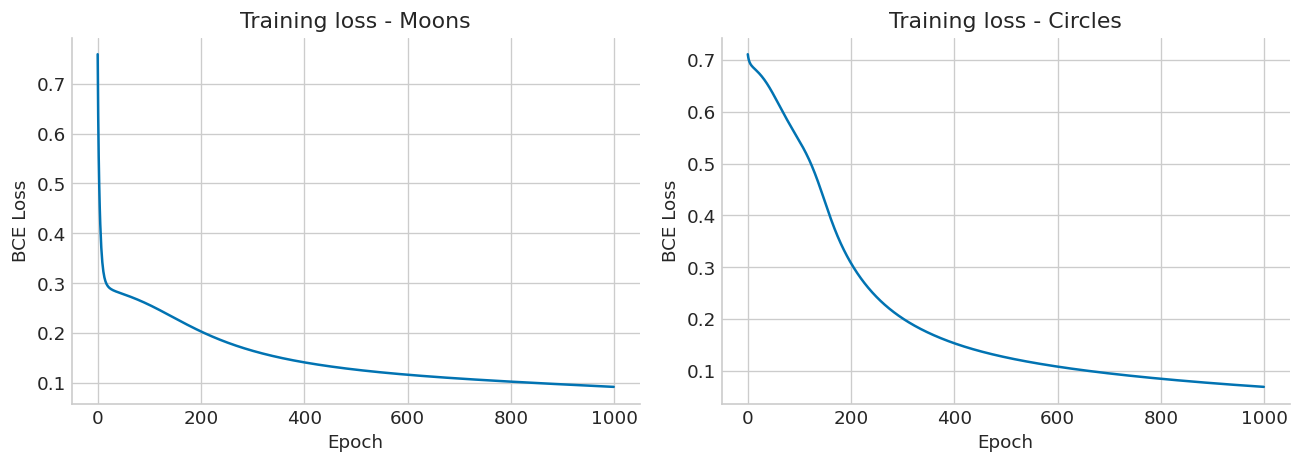

In [15]:
# ── Loss curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, loss, title in zip(axes,
                            [loss_m, loss_c],
                            ['Moons', 'Circles']):
    ax.plot(loss, lw=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.set_title(f'Training loss - {title}')
plt.tight_layout()
plt.show()

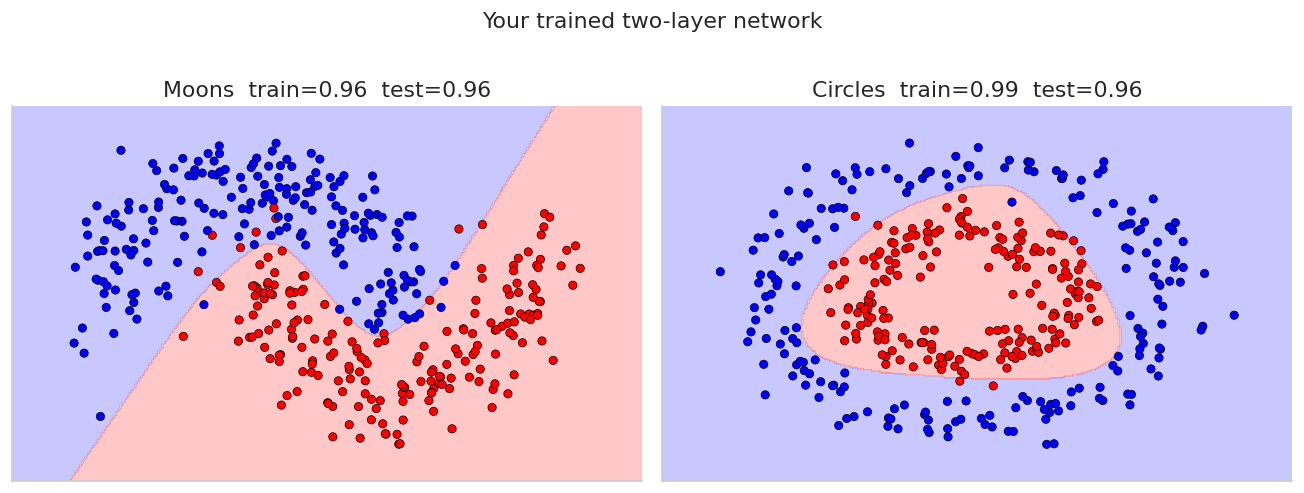

In [16]:
# ── Decision boundaries ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (Xtr, Xte, ytr, yte, params, name) in zip(
        axes,
        [(Xm_tr, Xm_te, ym_tr, ym_te, params_m, 'Moons'),
         (Xc_tr, Xc_te, yc_tr, yc_te, params_c, 'Circles')]):
    acc_tr = accuracy_score(ytr, nn.predict(Xtr, params))
    acc_te = accuracy_score(yte, nn.predict(Xte, params))
    plot_decision_boundary(
        lambda X, p=params: nn.predict(X, p),
        np.vstack([Xtr, Xte]),
        np.concatenate([ytr, yte]),
        title=f'{name}  train={acc_tr:.2f}  test={acc_te:.2f}',
        ax=ax)
plt.suptitle('Your trained two-layer network', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Classification Reports

In [17]:
for Xte, yte, params, name in [
        (Xm_te, ym_te, params_m, 'Moons'),
        (Xc_te, yc_te, params_c, 'Circles')]:
    print(f'=== {name} - Test Set ===')
    print(classification_report(yte, nn.predict(Xte, params),
                                 target_names=['Class 0', 'Class 1']))

=== Moons - Test Set ===
              precision    recall  f1-score   support

     Class 0       0.94      0.98      0.96        50
     Class 1       0.98      0.94      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100

=== Circles - Test Set ===
              precision    recall  f1-score   support

     Class 0       0.93      1.00      0.96        50
     Class 1       1.00      0.92      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



### 3.3 Порівняння з \MLPClassifier\ з бібліотеки sklearn

Навчимо еквівалентну мережу за допомогою sklearn та порівняємо результати.  
Обидві мережі використовують однакову архітектуру: **2 → 8 → 1**, прихований шар tanh, вихід sigmoid.

In [18]:
results = []

for Xtr, Xte, ytr, yte, params_custom, name in [
        (Xm_tr, Xm_te, ym_tr, ym_te, params_m, 'Moons'),
        (Xc_tr, Xc_te, yc_tr, yc_te, params_c, 'Circles')]:

    # sklearn MLP - equivalent architecture
    mlp = MLPClassifier(
        hidden_layer_sizes=(8,),
        activation='tanh',
        solver='sgd',
        learning_rate_init=0.5,
        max_iter=1000,
        random_state=SEED
    )
    mlp.fit(Xtr, ytr)

    custom_acc = accuracy_score(yte, nn.predict(Xte, params_custom))
    sklearn_acc = accuracy_score(yte, mlp.predict(Xte))
    results.append((name, custom_acc, sklearn_acc))

print(f'  {"Dataset":<10}  {"Your NN":>10}  {"sklearn MLP":>12}')
print('  ' + '─' * 36)
for name, ca, sa in results:
    print(f'  {name:<10}  {ca:>10.4f}  {sa:>12.4f}')

  Dataset        Your NN   sklearn MLP
  ────────────────────────────────────
  Moons           0.9600        0.9600
  Circles         0.9600        0.9800


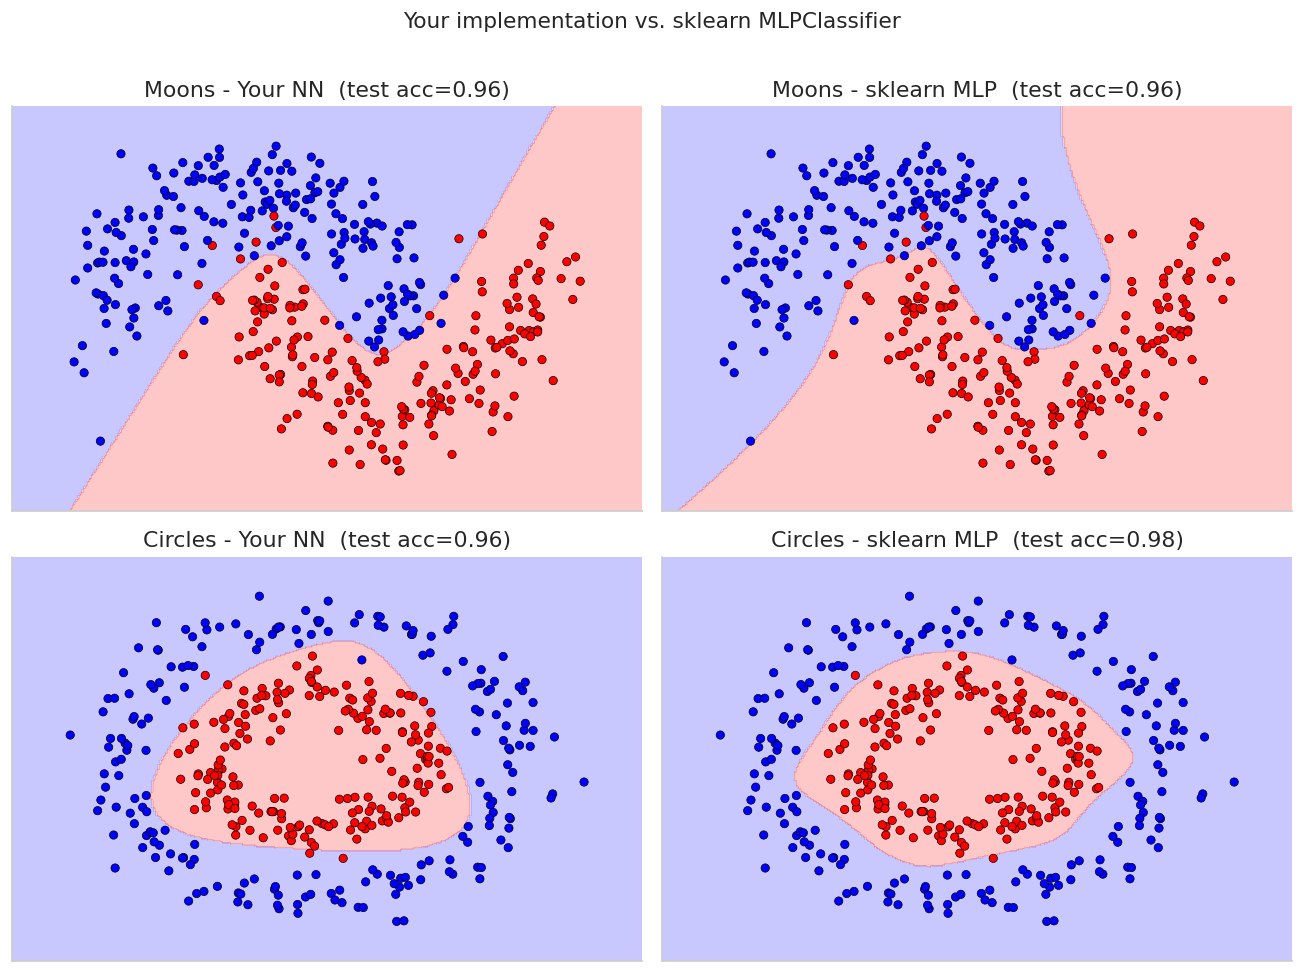

In [19]:
# ── Side-by-side decision boundaries: yours vs sklearn ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

configs = [
    (Xm_tr, Xm_te, ym_tr, ym_te, params_m, 'Moons'),
    (Xc_tr, Xc_te, yc_tr, yc_te, params_c, 'Circles'),
]

for row, (Xtr, Xte, ytr, yte, params_custom, name) in enumerate(configs):
    X_all = np.vstack([Xtr, Xte])
    y_all = np.concatenate([ytr, yte])

    # sklearn
    mlp = MLPClassifier(hidden_layer_sizes=(8,), activation='tanh',
                        solver='sgd', learning_rate_init=0.5,
                        max_iter=1000, random_state=SEED)
    mlp.fit(Xtr, ytr)

    # Your network
    acc_custom  = accuracy_score(yte, nn.predict(Xte, params_custom))
    acc_sklearn = accuracy_score(yte, mlp.predict(Xte))

    plot_decision_boundary(
        lambda X, p=params_custom: nn.predict(X, p),
        X_all, y_all,
        title=f'{name} - Your NN  (test acc={acc_custom:.2f})',
        ax=axes[row, 0])

    plot_decision_boundary(
        mlp.predict, X_all, y_all,
        title=f'{name} - sklearn MLP  (test acc={acc_sklearn:.2f})',
        ax=axes[row, 1])

plt.suptitle('Your implementation vs. sklearn MLPClassifier', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Loss Curve Comparison

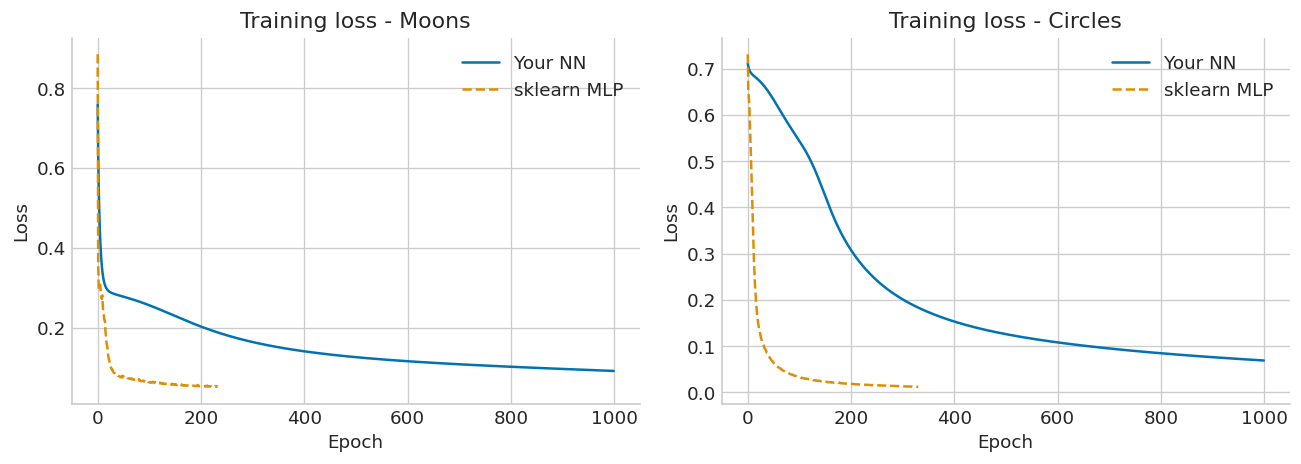

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (Xtr, ytr, loss_custom, name) in zip(
        axes,
        [(Xm_tr, ym_tr, loss_m, 'Moons'),
         (Xc_tr, yc_tr, loss_c, 'Circles')]):

    mlp = MLPClassifier(hidden_layer_sizes=(8,), activation='tanh',
                        solver='sgd', learning_rate_init=0.5,
                        max_iter=1000, random_state=SEED)
    mlp.fit(Xtr, ytr)

    ax.plot(loss_custom,    label='Your NN',      lw=1.5)
    ax.plot(mlp.loss_curve_, label='sklearn MLP', lw=1.5, ls='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Training loss - {name}')
    ax.legend()

plt.tight_layout()
plt.show()

> **Очікуваний результат:** Обидві криві мають збігатися до схожого фінального значення втрат. Незначні відмінності є нормою — sklearn використовує додаткові прийоми (імпульс, адаптивні розклади, рання зупинка), яких немає у нашій простій реалізації SGD.

---
## Бонус — Дослідження гіперпараметрів

Змініть параметри нижче та спостерігайте, як змінюється навчання і межа рішення.

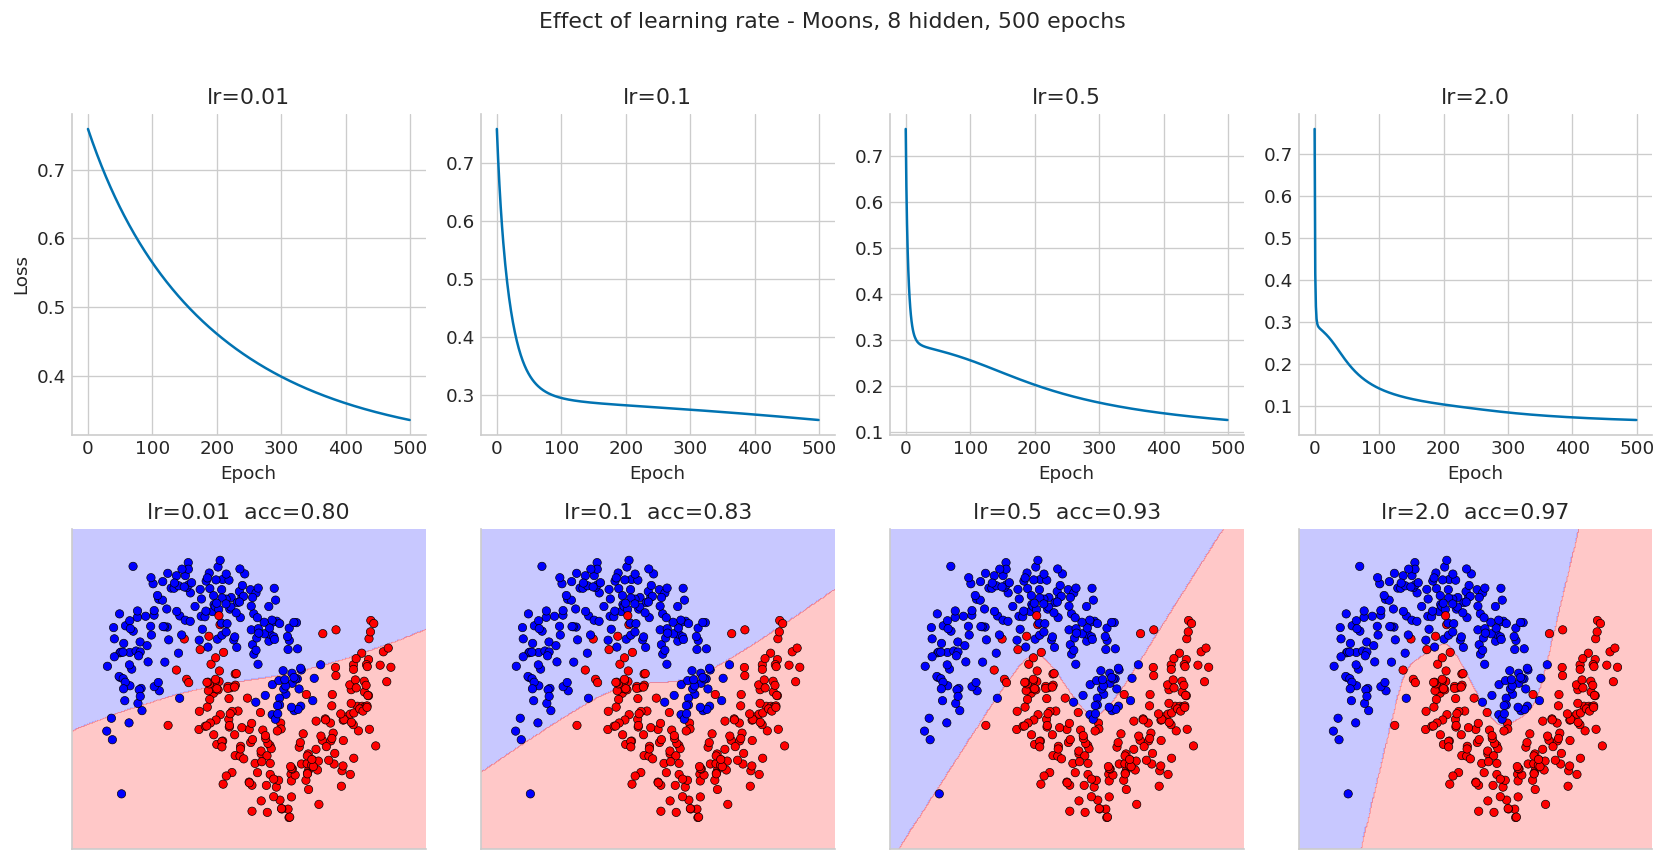

In [21]:
importlib.reload(nn)

# ── Experiment: vary learning rate ─────────────────────────────────────────
learning_rates = [0.01, 0.1, 0.5, 2.0]

fig, axes = plt.subplots(2, len(learning_rates), figsize=(14, 7))
for col, lr in enumerate(learning_rates):
    params_exp, curve_exp = nn.train(
        Xm_tr, ym_tr, n_hidden=8, lr=lr, n_epochs=500, seed=SEED, verbose=False)
    acc = accuracy_score(ym_te, nn.predict(Xm_te, params_exp))

    axes[0, col].plot(curve_exp, lw=1.5)
    axes[0, col].set_title(f'lr={lr}')
    axes[0, col].set_xlabel('Epoch')
    if col == 0: axes[0, col].set_ylabel('Loss')

    plot_decision_boundary(
        lambda X, p=params_exp: nn.predict(X, p),
        np.vstack([Xm_tr, Xm_te]),
        np.concatenate([ym_tr, ym_te]),
        title=f'lr={lr}  acc={acc:.2f}',
        ax=axes[1, col])

plt.suptitle('Effect of learning rate - Moons, 8 hidden, 500 epochs', y=1.02)
plt.tight_layout()
plt.show()

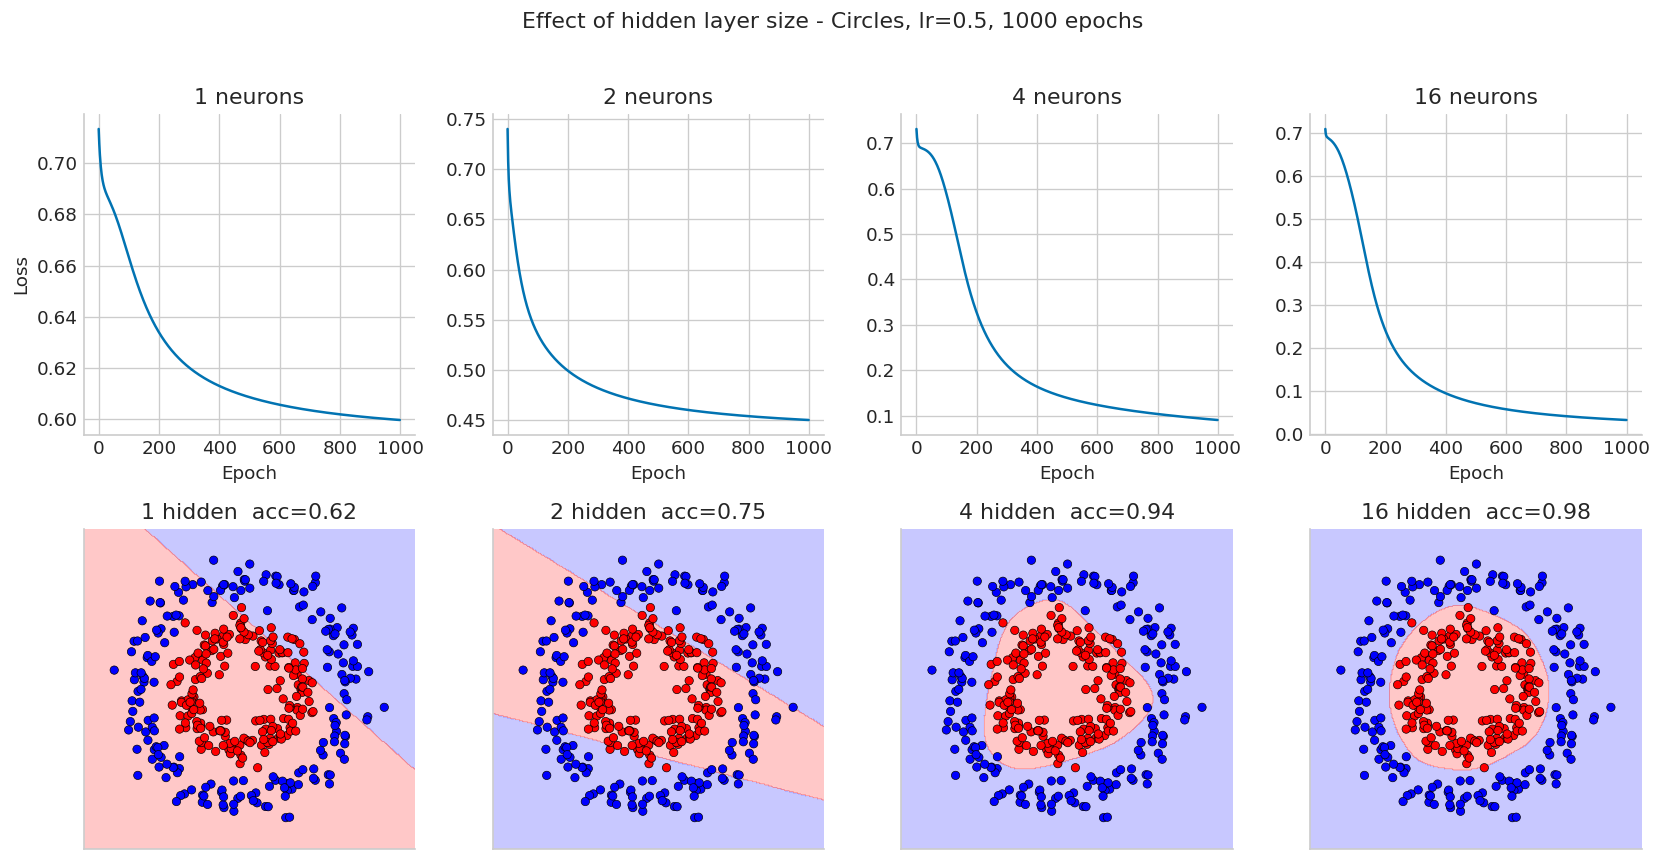

In [22]:
# ── Experiment: vary number of hidden neurons ───────────────────────────────
hidden_sizes = [1, 2, 4, 16]

fig, axes = plt.subplots(2, len(hidden_sizes), figsize=(14, 7))
for col, h in enumerate(hidden_sizes):
    params_exp, curve_exp = nn.train(
        Xc_tr, yc_tr, n_hidden=h, lr=0.5, n_epochs=1000, seed=SEED, verbose=False)
    acc = accuracy_score(yc_te, nn.predict(Xc_te, params_exp))

    axes[0, col].plot(curve_exp, lw=1.5)
    axes[0, col].set_title(f'{h} neurons')
    axes[0, col].set_xlabel('Epoch')
    if col == 0: axes[0, col].set_ylabel('Loss')

    plot_decision_boundary(
        lambda X, p=params_exp: nn.predict(X, p),
        np.vstack([Xc_tr, Xc_te]),
        np.concatenate([yc_tr, yc_te]),
        title=f'{h} hidden  acc={acc:.2f}',
        ax=axes[1, col])

plt.suptitle('Effect of hidden layer size - Circles, lr=0.5, 1000 epochs', y=1.02)
plt.tight_layout()
plt.show()

---
## Підсумок

У цій лабораторній роботі ви реалізували двошарову нейронну мережу повністю з нуля:

| Що реалізовано | Ключова ідея |
|----------------|-------------|
| Похідні sigmoid, tanh | Необхідні для зворотного ходу; насичуються на крайніх значеннях |
| Ініціалізація Xavier | Утримує активації в розумних межах на початку навчання |
| Прямий хід | Обчислює \ = XW^\top + b\$, \ = \sigma(Z)\$ для кожного шару |
| Зворотний хід | Поширює градієнти через правило ланцюжка |
| Перевірка градієнтів | Перевіряє правильність реалізації через чисельну апроксимацію |
| Навчальний цикл | Обновлює ваги за допомогою SGD |